# Analyse results from Pypsa-Earth

Sources: 
- Plot capacity - map view: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/viz/regional_transm_system_viz.ipynb
- Analyse energy potential: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/build_renewable_profiles.ipynb
- Analyse energy generation: https://pypsa.readthedocs.io/en/latest/examples/statistics.html

Some files are needed:
* PyPSA network file (e.g. "elec.nc" contains a lot of details and looks perfect)
* a country shape file (may be found in "resources/shapes/country_shapes.geojson")
* a renewable profile file (may be found in "resources/renewable_profiles/....nc)

## Own setting

In [53]:
import os
import sys
import yaml

PARENT = os.path.realpath("../../pypsa-earth") + "/"
# config = yaml.safe_load(open(PARENT + "config-2030-NetZero-3TWh-Hydro.yaml"))
config = yaml.safe_load(open(PARENT + "config-2030_DZ-GADM-el-inclIsolated-12H-netZero.yaml"))
# config = yaml.safe_load(open(PARENT + "config.yaml"))

# Read config.yaml settings:
name = config["run"]["name"]
simpl = config["scenario"]["simpl"]
# clusters = "10"
clusters = config["scenario"]["clusters"]
ll = config["scenario"]["ll"]
opts = config["scenario"]["opts"]

# Ensure elements are strings and properly joined
simpl_str = "_".join(map(str, simpl))
clusters_str = "_".join(map(str, clusters))
#clusters_str = clusters
ll_str = "_".join(map(str, ll))
opts_str = "_".join(map(str, opts))
export = "1"
geothermal_potential = "3"

## Import packages

In [7]:
import yaml
import pypsa
import warnings
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
from datetime import datetime
from cartopy import crs as ccrs
from pypsa.plot import add_legend_circles, add_legend_lines, add_legend_patches
import os
import xarray as xr
import cartopy

## Path settings

In [51]:
# nc_file_name = f"elec_s{simpl_str}_{clusters_str}_ec_l{ll_str}_{opts_str}-{export}-{geothermal_potential}.nc"
nc_file_name = f"elec_s{simpl_str}_{clusters_str}_ec_l{ll_str}_{opts_str}.nc"
scenario_name = name 
scenario_subpath = scenario_name + "/" if scenario_name else ""

# Network file
results_path = PARENT + f"results/{scenario_subpath}networks/{nc_file_name}"
network_path = PARENT + f"networks/{scenario_subpath}elec.nc"
# Country shape file
regions_onshore_path = PARENT + f"resources/{scenario_subpath}shapes/country_shapes.geojson"
# Renewable profile file
solar_path = PARENT + f"resources/{scenario_subpath}renewable_profiles/profile_solar.nc"
onwind_path = PARENT + f"resources/{scenario_subpath}renewable_profiles/profile_onwind.nc"

## Energy system analysis setup - power and energy generation

In [52]:
warnings.simplefilter(action='ignore', category=FutureWarning)
n = pypsa.Network(results_path)
regions_onshore = gpd.read_file(regions_onshore_path)
country_coordinates = regions_onshore.total_bounds[[0, 2, 1, 3]]
warnings.simplefilter(action='default', category=FutureWarning)

INFO:pypsa.io:Imported network elec_s_48_ec_lcopt_Co2L-12H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


## Data import check

Country check

Text(0.5, 1.0, 'DZ')

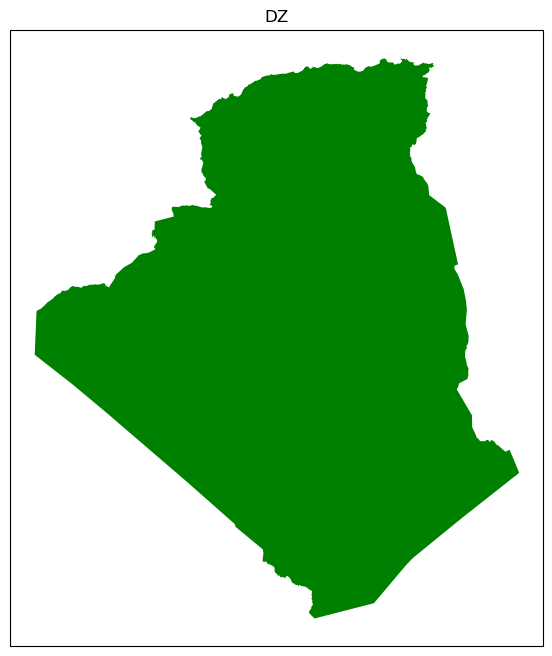

In [10]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
with plt.rc_context({"patch.linewidth": 0.}):
    regions_onshore.plot(
    ax=ax,
    facecolor="green",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
    )
ax.set_title(", ".join(regions_onshore.name.values))

Component check

In [11]:
for c in n.iterate_components(list(n.components.keys())[2:]):
    print("Component '{}' has {} entries".format(c.name,len(c.df)))

Component 'Bus' has 141 entries
Component 'Carrier' has 18 entries
Component 'GlobalConstraint' has 1 entries
Component 'Line' has 96 entries
Component 'LineType' has 34 entries
Component 'TransformerType' has 14 entries
Component 'Link' has 188 entries
Component 'Load' has 47 entries
Component 'Generator' has 268 entries
Component 'StorageUnit' has 1 entries
Component 'Store' has 94 entries


In [12]:
buses = n.buses.loc[n.buses['carrier']=='AC']
buses_geo = gpd.points_from_xy(buses["lon"], buses["lat"])
buses_gdf = gpd.GeoDataFrame(buses, geometry=buses_geo, crs=4326)


In [13]:
buses_gdf.explore()

Snapshot check

In [14]:
print(n.snapshots)
print(f"Time steps: " + str(len(n.snapshots)))

DatetimeIndex(['2013-01-01 00:00:00', '2013-01-01 12:00:00',
               '2013-01-02 00:00:00', '2013-01-02 12:00:00',
               '2013-01-03 00:00:00', '2013-01-03 12:00:00',
               '2013-01-04 00:00:00', '2013-01-04 12:00:00',
               '2013-01-05 00:00:00', '2013-01-05 12:00:00',
               ...
               '2013-12-27 00:00:00', '2013-12-27 12:00:00',
               '2013-12-28 00:00:00', '2013-12-28 12:00:00',
               '2013-12-29 00:00:00', '2013-12-29 12:00:00',
               '2013-12-30 00:00:00', '2013-12-30 12:00:00',
               '2013-12-31 00:00:00', '2013-12-31 12:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=730, freq=None)
Time steps: 730


## Analyse energy system

Analyse the current capacity of the energy system - map view

/home/marco-s/miniconda3/envs/pypsa-earth-2/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


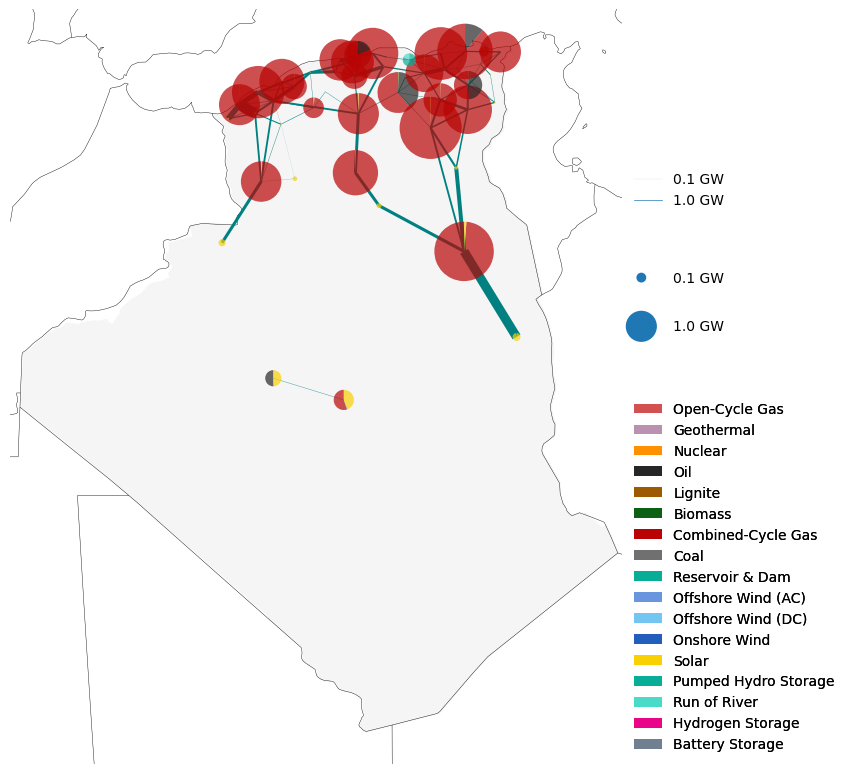

In [16]:
# Scale settings
bus_scale = 3e3 
line_scale = 2e3

# Legend settings
bus_sizes = [100, 1000]  # in MW
line_sizes = [100, 1000]  # in MW

# n-noLoad = n.carriers.drop("Load", inplace=False)
n.carriers.drop("Load", inplace=True)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
gen = n.generators[(n.generators.carrier != "load") & (n.generators.carrier != "export")].groupby(["bus", "carrier"]).p_nom.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom.sum()
buses = pd.concat([gen, sto])

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom_opt / line_scale,
        link_widths=n.links[n.links.carrier != "export"].p_nom_opt / line_scale,
        line_colors="teal",
        ax=ax,
        margin=0.1,
        color_geomap=None,
    )
regions_onshore.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
)
ax.set_extent(regions_onshore.total_bounds[[0, 2, 1, 3]])

# Make more space at bottom to not cut off capacity circle
ylims = ax.get_ylim()  # Get current y-axis limits
ax.set_ylim(ylims[0] - 1e5, ylims[1] + 1e5)  # Extend the bottom and top by shifting downward + upward

legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw=legend_circles_dict,    
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
)
add_legend_patches(
    ax,
    n.carriers.color,
    n.carriers.nice_name,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc":"lower left"},
)
fig.tight_layout()
fig.savefig("brownfield_capacities_" + scenario_name + ".png", bbox_inches="tight", dpi=300)

Analyse the current generation capacity of the energy system - pie chart view

Text(0.5, 1.0, 'Generator Capacity by Carrier')

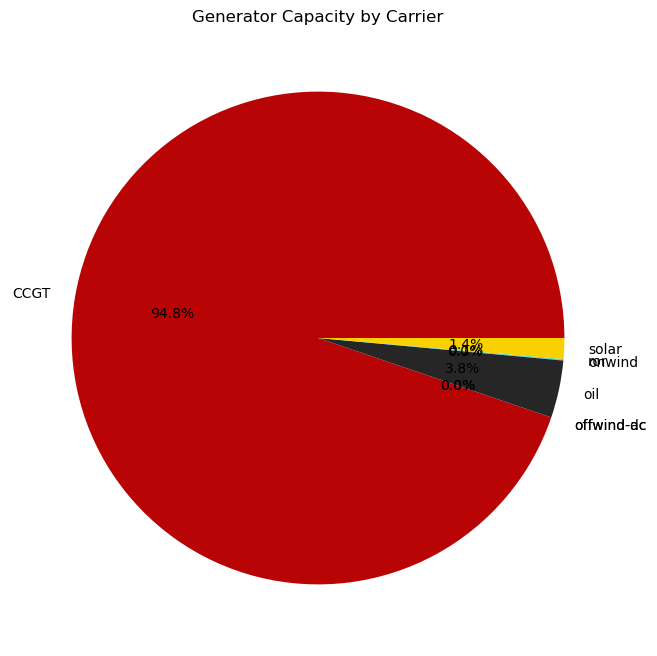

In [17]:
generator_capacity_by_carrier = n.generators[(n.generators.carrier != "load") & (n.generators.carrier != "export")].groupby(["carrier"]).p_nom.sum()
plt.figure(figsize=(8, 8))
plt.pie(generator_capacity_by_carrier, labels=generator_capacity_by_carrier.index, autopct='%1.1f%%', colors=n.carriers[n.carriers.index.isin(generator_capacity_by_carrier.index)].color.reindex(generator_capacity_by_carrier.index))
plt.title("Generator Capacity by Carrier")

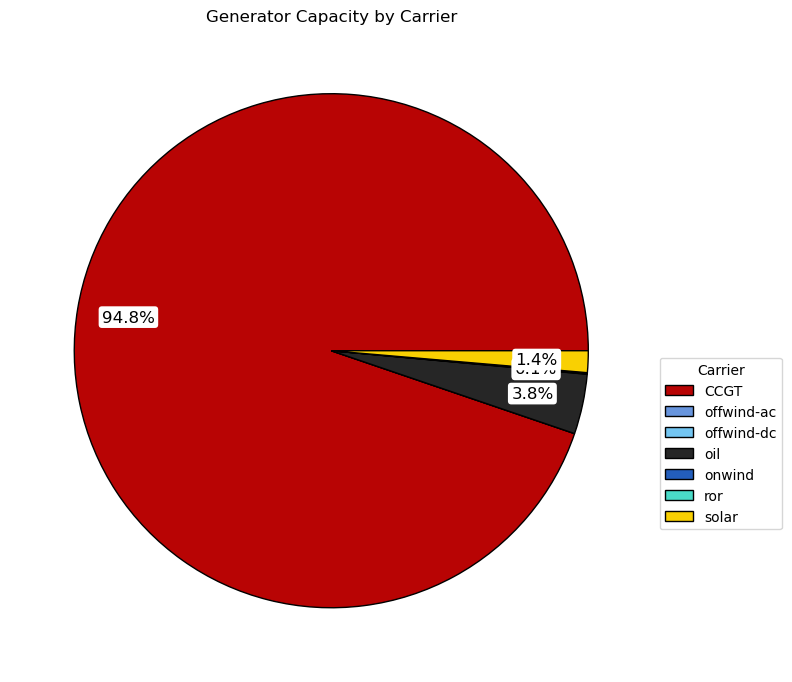

In [21]:
generator_capacity_by_carrier = n.generators[
    (n.generators.carrier != "load") & (n.generators.carrier != "export")
].groupby(["carrier"]).p_nom.sum()

colors = n.carriers[n.carriers.index.isin(generator_capacity_by_carrier.index)].color.reindex(generator_capacity_by_carrier.index)

plt.figure(figsize=(8, 8))

# Plot pie chart with leader lines
wedges, texts, autotexts = plt.pie(
    generator_capacity_by_carrier, 
    labels=None,  # Remove labels from pie itself
    autopct=lambda pct: f"{pct:.1f}%" if pct > 0.01 else "",  # Hide very small percentages
    colors=colors, 
    pctdistance=0.8,  # Move percentages outward
    labeldistance=1.2,  # Move labels further out
    wedgeprops={'edgecolor': 'black'},  # Improve slice visibility
    textprops={'fontsize': 12}  # Adjust text size
)

# Add leader lines automatically
for i, autotext in enumerate(autotexts):
    autotext.set_horizontalalignment('center')
    autotext.set_bbox(dict(facecolor='white', edgecolor='None', boxstyle='round,pad=0.2'))

# Add a legend instead of direct labels
plt.legend(wedges, generator_capacity_by_carrier.index, title="Carrier", loc="best", bbox_to_anchor=(1, 0.5))

plt.title("Generator Capacity by Carrier")
plt.tight_layout()
plt.show()

Analyse the current gernation capacity of the energy system - tabular view

In [22]:
generator_capacity_by_carrier/1e3 # in GW

carrier
CCGT          29.635056
offwind-ac     0.000000
offwind-dc     0.000000
oil            1.176446
onwind         0.009506
ror            0.021378
solar          0.425800
Name: p_nom, dtype: float64

Analyse the future capacity of the energy system - map view

/home/marco-s/miniconda3/envs/pypsa-earth-2/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


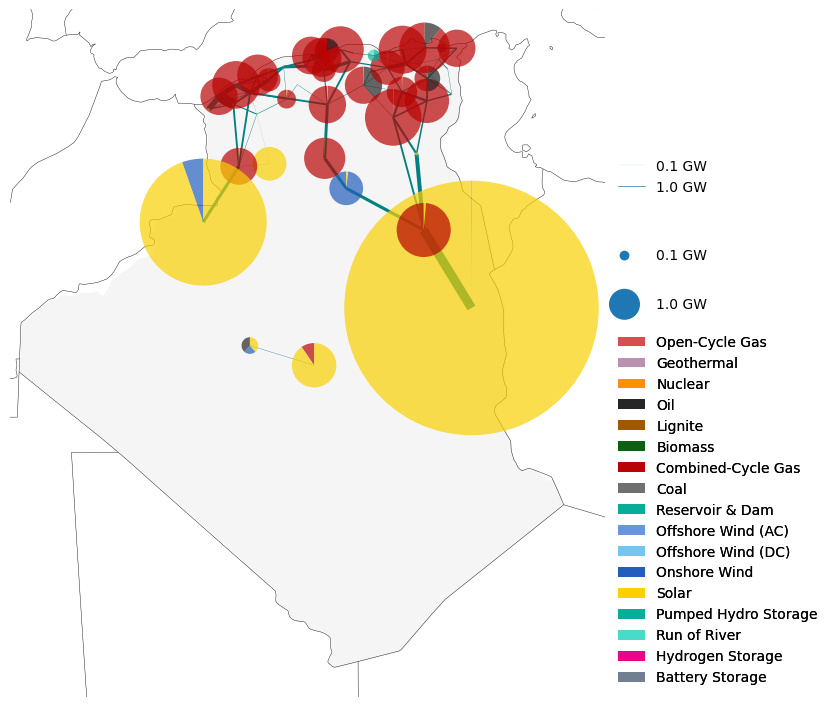

In [26]:
bus_scale = 3e3 
line_scale = 2e3

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
gen = n.generators[(n.generators.carrier != "load") & (n.generators.carrier != "export")].groupby(["bus", "carrier"]).p_nom_opt.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom_opt.sum()
buses = pd.concat([gen, sto])

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom_opt / line_scale,
        link_widths=n.links[n.links.carrier != "export"].p_nom_opt / line_scale,
        line_colors="teal",
        ax=ax,
        margin=0.2,
        color_geomap=None,
    )
regions_onshore.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
)
ax.set_extent(regions_onshore.total_bounds[[0, 2, 1, 3]])

# Make more space at bottom to not cut off capacity circle
ylims = ax.get_ylim()  # Get current y-axis limits
ax.set_ylim(ylims[0] - 1e5, ylims[1] + 1e5)  # Extend the bottom by shifting downward
xlims = ax.get_xlim()
ax.set_xlim(xlims[0], xlims[1] +1.3e5)

legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw=legend_circles_dict,    
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
)
add_legend_patches(
    ax,
    n.carriers.color,
    n.carriers.nice_name,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc":"lower left"},
)
fig.tight_layout()

Calculate emissions of future energy system

In [27]:
#ToDo: Not fully correct - double check
co2_emissions = pd.DataFrame(data=n.carriers[["co2_emissions", "nice_name"]]).set_index("nice_name").squeeze().rename_axis("carrier")

energy_production = n.statistics.energy_balance().Generator.droplevel(1).drop(["load", "export"], errors="ignore")

co2_emissions_technology = energy_production * co2_emissions.loc[energy_production.index] * n.snapshot_weightings.generators[0]
co2_emissions_technology

/tmp/ipykernel_701/272665663.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  co2_emissions_technology = energy_production * co2_emissions.loc[energy_production.index] * n.snapshot_weightings.generators[0]


carrier
Offshore Wind (AC)    0.0
Onshore Wind          0.0
Run of River          0.0
Solar                 0.0
dtype: float64

In [28]:
co2_emissions_sum = co2_emissions_technology.sum()
co2_emissions_sum

0.0

In [ ]:
n.global_constraints

,sense,mu,type,investment_period,carrier_attribute,constant
GlobalConstraint,,,,,,
CO2Limit,<=,-10547.859271,primary_energy,NaN,co2_emissions,0.0


Analys the future generation capacity expansion of the energy system - bar chart

In [30]:
generation_capacity_expansion = n.statistics.optimal_capacity(comps=["Generator"]).droplevel(0).div(1e3)-n.statistics.installed_capacity(comps=["Generator"]).droplevel(0).div(1e3)
generation_capacity_expansion

carrier
Combined-Cycle Gas     0.000000
Offshore Wind (AC)          NaN
Oil                    0.000000
Onshore Wind           1.807775
Run of River           0.000000
Solar                 71.238540
load                   0.000000
dtype: float64

Plot the future generation capacity expansion of the energy system - tabular chart

<AxesSubplot:title={'center':'Generator capacity expansion in GW'}, xlabel='carrier'>

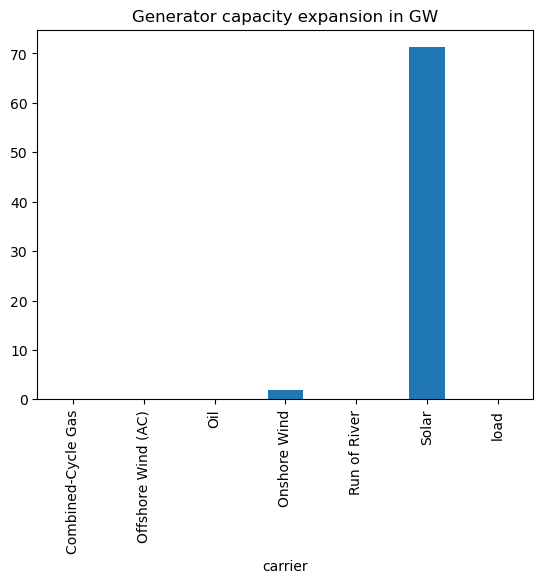

In [31]:
generation_capacity_expansion = n.statistics.optimal_capacity(comps=["Generator"]).droplevel(0).div(1e3)-n.statistics.installed_capacity(comps=["Generator"]).droplevel(0).div(1e3)
generation_capacity_expansion.plot.bar(title="Generator capacity expansion in GW")

Analyse the future energy generation of the energy system - bar chart view

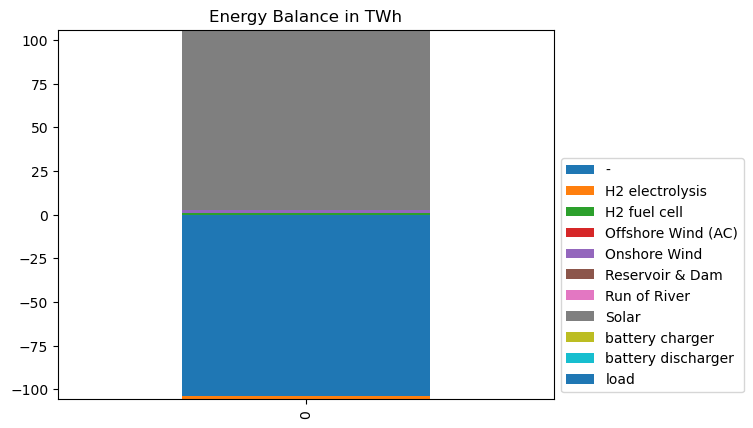

In [32]:
fig, ax = plt.subplots()
color_setting = n.carriers.set_index(n.carriers.nice_name)
energy_balance = n.statistics.energy_balance().loc[:, :, "AC"].groupby("carrier").sum().div(1e6).to_frame().T
energy_balance.plot.bar(stacked=True, ax=ax, title="Energy Balance in TWh")
n.carriers[n.carriers.index.isin(generator_capacity_by_carrier.index)].color.reindex(generator_capacity_by_carrier.index)

ax.legend(bbox_to_anchor=(1, 0), loc="lower left", title=None, ncol=1)

In [48]:
n.carriers.color

Carrier
OCGT            #d35050
geothermal      #ba91b1
nuclear         #ff9000
oil             #262626
lignite         #9e5a01
biomass         #0c6013
CCGT            #b80404
coal            #707070
hydro           #08ad97
offwind-ac      #6895dd
offwind-dc      #74c6f2
onwind          #235ebc
solar           #f9d002
PHS             #08ad97
ror             #4adbc8
H2              #ea048a
battery       slategray
Name: color, dtype: object

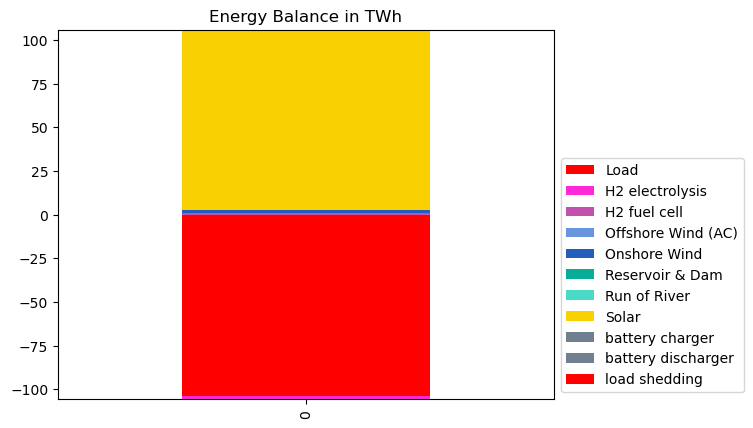

In [54]:
colors = {key.lower(): value.lower() for key, value in config["plotting"]["tech_colors"].items()}
nice_names = {value.lower(): key for key, value in config["plotting"]["nice_names"].items()}

rename_cols = {
    '-': 'Load',
    'load': 'load shedding',
}

energy_balance = (
    n.statistics.energy_balance()
    .loc[:, :, "AC"]
    .groupby("carrier")
    .sum()
    .div(1e6)
    .to_frame()
    .T
    .rename(columns=rename_cols)
)

# color-matching
color_list = []
for col in energy_balance.columns:
    original_name = col.lower()
    key_name = nice_names.get(original_name, original_name)
    color = colors.get(key_name.lower(), 'gray')
    color_list.append(color)


fig, ax = plt.subplots()
energy_balance.plot.bar(stacked=True, ax=ax, title="Energy Balance in TWh", color=color_list)
handles, labels = ax.get_legend_handles_labels()
nice_labels = [config["plotting"]["nice_names"].get(label, label) for label in energy_balance.columns]
ax.legend(handles, nice_labels, bbox_to_anchor=(1, 0), loc="lower left", title=None, ncol=1)

plt.show()

Analyse the future energy generation of the energy system - tabular view

In [57]:
n.statistics.energy_balance().loc[:,:,'AC'] / 1e6 # TWh

component    carrier           
StorageUnit  Reservoir & Dam       1.221527e-01
Load         -                    -1.040156e+02
Link         H2 electrolysis      -1.838293e+00
             battery charger      -5.213015e-04
             H2 fuel cell          8.529678e-01
             battery discharger    4.222624e-04
Generator    Offshore Wind (AC)    3.020358e-08
             Onshore Wind          1.648067e+00
             Run of River          1.867523e-01
             Solar                 1.030441e+02
             load                  1.300899e-08
dtype: float64

## Analyse pv and wind potential - map view

In [58]:
solar = xr.open_dataset(solar_path)
wind = xr.open_dataset(onwind_path)

def plot_voronoi(n, carrier, voronoi, cmap, projection, title=None, filename=None):
    g = n.generators.loc[n.generators.carrier == carrier]
    # br = gpd.read_file(f"resources/{scenario_name}/bus_regions/regions_{voronoi}.geojson").set_index("name")
    br = gpd.read_file(PARENT + f"resources/{scenario_name}/bus_regions/regions_{voronoi}.geojson").set_index("name")
    br_area = br.to_crs("ESRI:54009")
    br_area = br_area.geometry.area * 1e-6
    br["p_nom_max"] = g.groupby("bus").sum().p_nom_max / br_area

    fig, ax = plt.subplots(figsize=(8, 4), subplot_kw={"projection": projection})
    plt.rcParams.update({"font.size": 10})
    br.plot(
        ax=ax,
        column="p_nom_max",
        transform=ccrs.PlateCarree(),
        linewidth=0.25,
        edgecolor="k",
        cmap=cmap,
        vmin=0,
        vmax=br["p_nom_max"].max(),
        legend=True,
        legend_kwds={"label": r"potential density"},
    )
    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS.with_scale("110m"))
    ax.set_extent(country_coordinates, crs=ccrs.PlateCarree()) 
    
    if title is not None:
        plt.title(title)

Plot pv energy potential

INFO:pypsa.io:Imported network elec.nc has buses, carriers, generators, lines, loads, storage_units, transformers


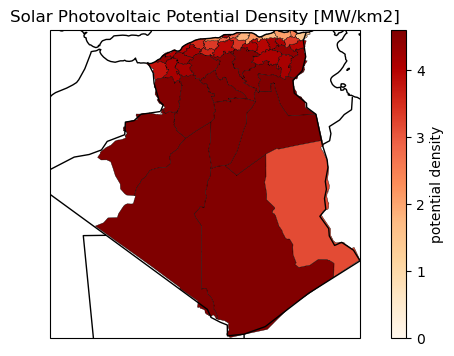

In [60]:
warnings.simplefilter(action='ignore', category=FutureWarning)
plot_voronoi(
    pypsa.Network(network_path),
    "solar",
    "onshore",
    "OrRd",
    ccrs.PlateCarree(),
    title="Solar Photovoltaic Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)

Plot wind energy potential

INFO:pypsa.io:Imported network elec.nc has buses, carriers, generators, lines, loads, storage_units, transformers


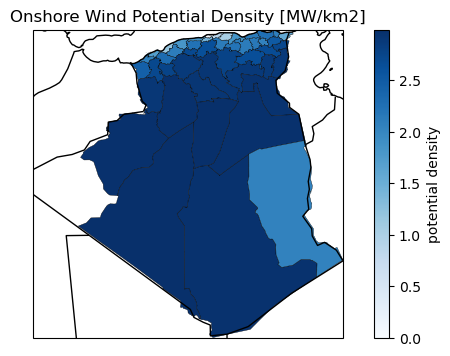

In [61]:
warnings.simplefilter(action='ignore', category=FutureWarning)
plot_voronoi(
    pypsa.Network(network_path),
    "onwind",
    "onshore",
    "Blues",
    ccrs.PlateCarree(),
    title="Onshore Wind Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)

Levelized cost of electricity

In [64]:
# Calculation levelzied cost of electricity in €/MWh based on overall costs and electricity generation
# n.statistics.market_value() ?
lcoe = n.objective/n.statistics.energy_balance().Generator.sum().round(2)
lcoe 

41.38223328760601

In [65]:
# Calculation levelzied cost of electricity in €/MWh based on overall costs and electricity demand
lcoe = n.objective/n.statistics.energy_balance().Load.sum()*(-1)
lcoe 

41.7256825750005

In [66]:
n.statistics.market_value()

component    carrier           
Generator    Offshore Wind (AC)     60.980792
             Onshore Wind          120.500485
             Run of River           47.886958
             Solar                  35.381612
             load                   43.886462
Line         AC                      1.126230
Link         H2 electrolysis        57.363948
             H2 fuel cell          104.777094
             battery charger         0.753175
             battery discharger     -0.944670
Load         -                            NaN
StorageUnit  Reservoir & Dam       336.010849
Store        Battery Storage       185.986626
             Hydrogen Storage       50.465329
dtype: float64

Check storages

In [67]:
n.storage_units

,carrier,bus,p_nom,max_hours,p_min_pu,efficiency_dispatch,efficiency_store,cyclic_state_of_charge,control,marginal_cost,...,marginal_cost_quadratic,capital_cost,build_year,lifetime,state_of_charge_initial,state_of_charge_initial_per_period,state_of_charge_set,cyclic_state_of_charge_per_period,standing_loss,inflow
StorageUnit,,,,,,,,,,,,,,,,,,,,,
DZ.8_1_AC hydro,hydro,DZ.8_1_AC,100.0,2710.628395,0.0,0.9,0.0,True,,0.00992,...,0.0,0.0,0,inf,0.0,False,NaN,True,0.0,0.0


## Additional input (Marco)

In [68]:
CCGT_col = [col for col in n.generators_t.p.columns if 'CCGT' in col]
n.generators_t.p[CCGT_col].sum()

Generator
DZ.10_1_AC CCGT    0.0
DZ.13_1_AC CCGT    0.0
DZ.16_1_AC CCGT    0.0
DZ.19_1_AC CCGT    0.0
DZ.23_1_AC CCGT    0.0
DZ.24_1_AC CCGT    0.0
DZ.25_1_AC CCGT    0.0
DZ.26_1_AC CCGT    0.0
DZ.28_1_AC CCGT    0.0
DZ.30_1_AC CCGT    0.0
DZ.31_1_AC CCGT    0.0
DZ.32_1_AC CCGT    0.0
DZ.33_1_AC CCGT    0.0
DZ.34_1_AC CCGT    0.0
DZ.35_1_AC CCGT    0.0
DZ.37_1_AC CCGT    0.0
DZ.39_1_AC CCGT    0.0
DZ.3_1_AC CCGT     0.0
DZ.41_1_AC CCGT    0.0
DZ.43_1_AC CCGT    0.0
DZ.45_1_AC CCGT    0.0
DZ.4_1_AC CCGT     0.0
DZ.5_1_AC CCGT     0.0
DZ.6_1_AC CCGT     0.0
DZ.9_1_AC CCGT     0.0
dtype: float64

Total load in 2013: 104.01562756805447 TWh


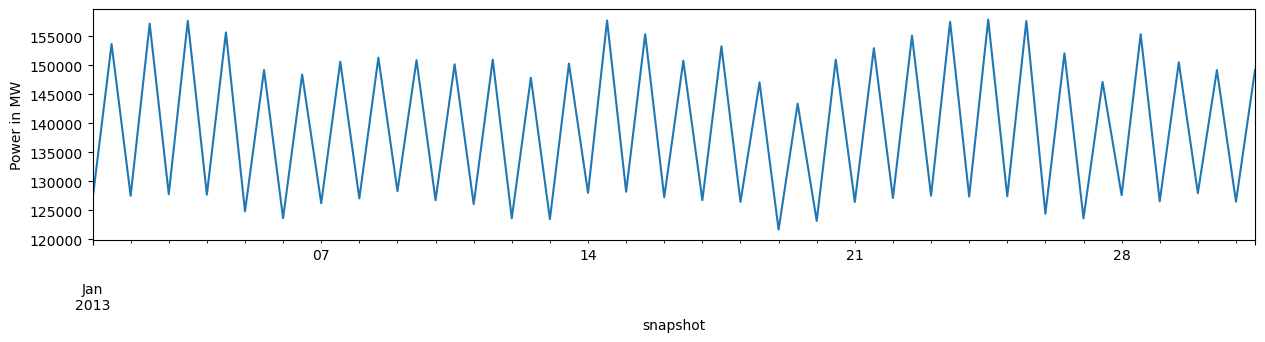

In [69]:
loads = n.loads_t.p.multiply(n.snapshot_weightings.generators, axis=0)
fig, ax = plt.subplots(figsize=(15, 3))
loads.sum(axis=1).loc['2013-01-01':'2013-01-31'].plot(ax=ax)
ax.set_ylabel('Power in MW')
print('Total load in 2013: {} TWh'.format(n.loads_t.p.multiply(n.snapshot_weightings.generators, axis=0).sum(axis=1).sum() / 1000000))

In [70]:
n.objective / 1e9 # billion europs p.a.
print("The total system cost is {:.0f} million euros per year".format(n.objective / 1e6))

The total system cost is 4340 million euros per year


## Line expansion

<AxesSubplot:xlabel='Line'>

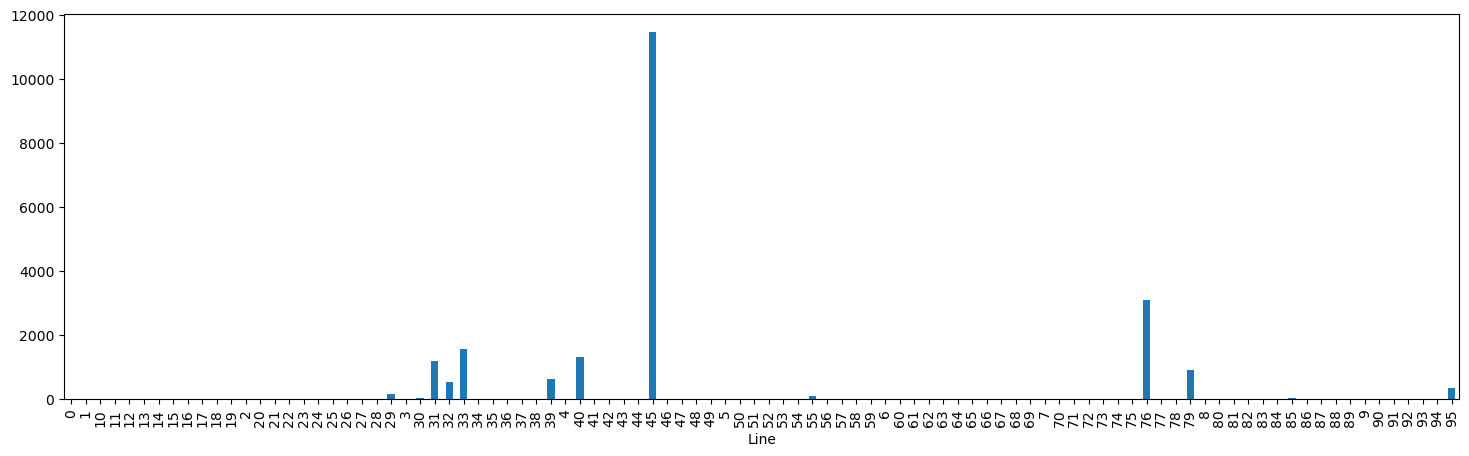

In [73]:
(n.lines.s_nom_opt - n.lines.s_nom).plot.bar(figsize=(18,5))

In [76]:
n.lines

,num_parallel,v_nom,bus0,bus1,length,dc,country,geometry,bounds,carrier,...,build_year,lifetime,terrain_factor,v_ang_min,v_ang_max,sub_network,x_pu,r_pu,g_pu,b_pu
Line,,,,,,,,,,,,,,,,,,,,,
0,0.618421,380.0,DZ.10_1_AC,DZ.13_1_AC,88.562954,False,DZ,MULTILINESTRING ((3.141550900000011 36.5976306...,MULTIPOINT ((3.141550900000011 36.597630699999...,AC,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
1,1.578947,380.0,DZ.10_1_AC,DZ.14_1_AC,175.107896,False,DZ,"LINESTRING (1.4922 36.2078, 1.5226634999999997...","MULTIPOINT ((1.4922 36.2078), (2.5783 36.4156))",AC,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
10,1.052632,380.0,DZ.12_1_AC,DZ.37_1_AC,168.562478,False,DZ,"MULTILINESTRING ((5.3175 35.8456, 5.3161515 35...",MULTIPOINT ((3.5749251999999996 36.25212579999...,AC,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
11,1.578947,380.0,DZ.13_1_AC,DZ.45_1_AC,134.034788,False,DZ,"MULTILINESTRING ((2.5932 36.4865, 2.6029175000...","MULTIPOINT ((2.5932 36.4865), (2.6029175000000...",AC,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
12,0.907895,380.0,DZ.13_1_AC,DZ.47_1_AC,62.928283,False,DZ,"MULTILINESTRING ((3.5928 36.7178, 3.5944165 36...","MULTIPOINT ((3.5928 36.7178), (3.5944165 36.71...",AC,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,0.289474,380.0,DZ.40_1_AC,DZ.42_1_AC,105.843237,False,DZ,"MULTILINESTRING ((7.894172 35.869523, 7.8934 3...","MULTIPOINT ((7.8934 35.8693), (7.894172 35.869...",AC,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
92,0.328947,380.0,DZ.43_1_AC,DZ.46_1_AC,77.162767,False,DZ,"MULTILINESTRING ((1.3580763 35.33924449999973,...","MULTIPOINT ((1.3488 35.3367), (1.3580762999999...",AC,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
93,0.815789,380.0,DZ.45_1_AC,DZ.4_1_AC,74.254623,False,DZ,MULTILINESTRING ((2.8216921384259184 36.620133...,"MULTIPOINT ((2.7801 36.6814), (2.8111429000000...",AC,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0


In [165]:
lines = n.lines
#lines["geometry"] = lines["geometry"].apply(loads)
lines_gdf = gpd.GeoDataFrame(lines, geometry="geometry")
lines_gdf.explore()

Text(0, 0.5, 'Capacity in GW')

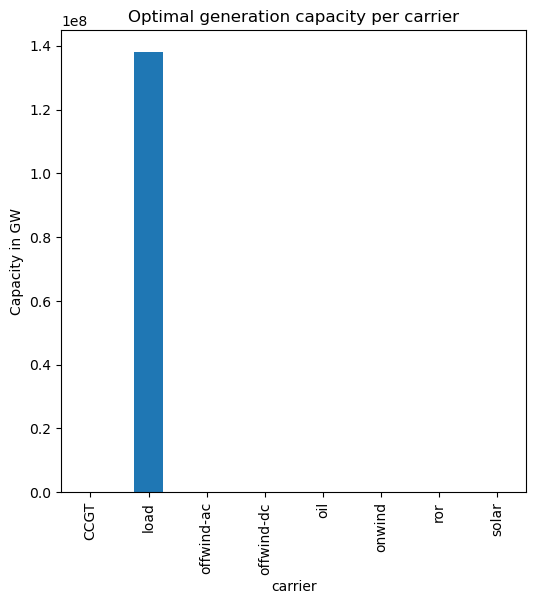

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
n.generators.groupby('carrier').p_nom_opt.sum().multiply(1e-3).plot.bar(ax = ax)
ax.set_title('Optimal generation capacity per carrier')
ax.set_ylabel('Capacity in GW')

In [ ]:
# n.generators.drop(n.generators[n.generators['carrier'] == 'load'], inplace=True)
n.generators = n.generators[n.generators['carrier'] != 'load']

In [ ]:
n.storage_units_t.state_of_charge / 1e6

StorageUnit,DZ.8_1_AC hydro
snapshot,
2013-01-01 00:00:00,0.102489
2013-01-01 12:00:00,0.101177
2013-01-02 00:00:00,0.099892
2013-01-02 12:00:00,0.099326
2013-01-03 00:00:00,0.098210
...,...
2013-12-29 12:00:00,0.107855
2013-12-30 00:00:00,0.107441
2013-12-30 12:00:00,0.106364


In [ ]:
n.storage_units

,carrier,bus,p_nom,max_hours,p_min_pu,efficiency_dispatch,efficiency_store,cyclic_state_of_charge,control,marginal_cost,...,marginal_cost_quadratic,capital_cost,build_year,lifetime,state_of_charge_initial,state_of_charge_initial_per_period,state_of_charge_set,cyclic_state_of_charge_per_period,standing_loss,inflow
StorageUnit,,,,,,,,,,,,,,,,,,,,,
DZ.8_1_AC hydro,hydro,DZ.8_1_AC,100.0,2710.628395,0.0,0.9,0.0,True,,0.00992,...,0.0,0.0,0,inf,0.0,False,NaN,True,0.0,0.0


Text(0.5, 1.0, 'State of charge in TWh')

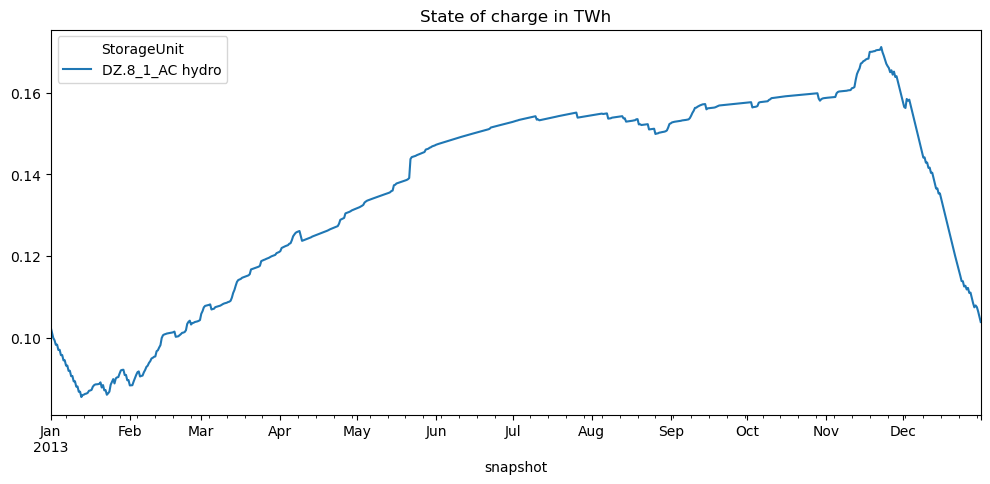

In [ ]:
fig, ax = plt.subplots(figsize=(12,5))
(n.storage_units_t.state_of_charge / 1e6).plot(ax = ax)
ax.set_title('State of charge in TWh')

In [ ]:
(n.storage_units_t.state_of_charge / 1e6)

StorageUnit,DZ.8_1_AC hydro
snapshot,
2013-01-01 00:00:00,0.102489
2013-01-01 12:00:00,0.101177
2013-01-02 00:00:00,0.099892
2013-01-02 12:00:00,0.099326
2013-01-03 00:00:00,0.098210
...,...
2013-12-29 12:00:00,0.107855
2013-12-30 00:00:00,0.107441
2013-12-30 12:00:00,0.106364


<AxesSubplot:xlabel='snapshot'>

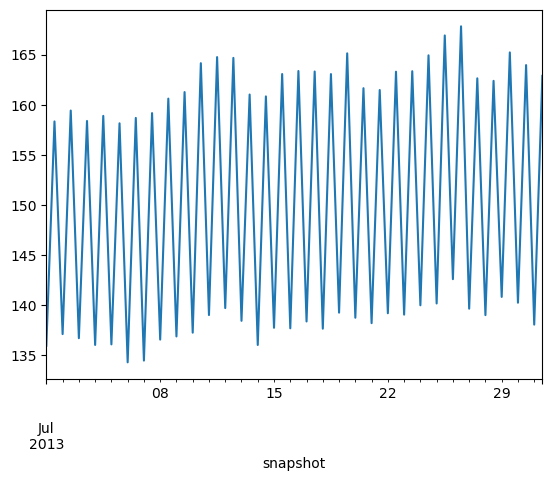

In [ ]:
(n.loads_t.p.sum(axis=1).multiply(n.snapshot_weightings.generators) / 1e3).loc['2013-07'].plot()

<AxesSubplot:xlabel='snapshot'>

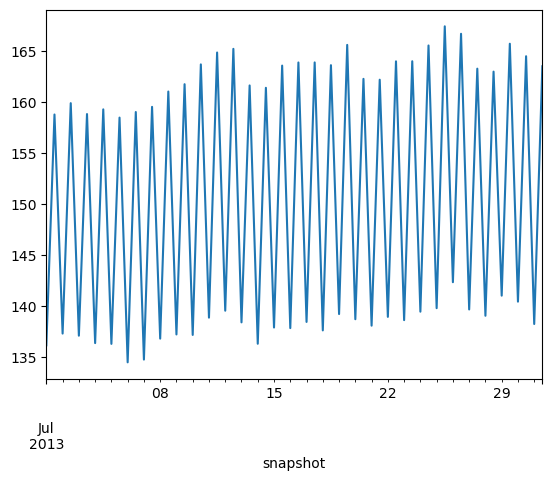

In [ ]:
(n.generators_t.p.sum(axis=1).multiply(n.snapshot_weightings.generators) / 1e3).loc['2013-07'].plot()

In [ ]:
n.statistics.supply() / 1e6

component    carrier           
StorageUnit  Reservoir & Dam       7.686043e+00
Line         AC                    2.769693e+01
Link         H2 electrolysis       6.938188e-01
             H2 fuel cell          4.024149e-01
             battery charger       2.722818e+00
             battery discharger    2.450536e+00
Store        Battery Storage       2.722279e+00
             Hydrogen Storage      6.934614e-01
Generator    Offshore Wind (DC)    2.986375e-08
             Onshore Wind          2.913540e-01
             Run of River          1.401528e+00
             Solar                 1.131490e+01
dtype: float64

In [ ]:
n.storage_units.p_nom * n.storage_units.max_hours

StorageUnit
GH.11_2_AC hydro    8.511236e+05
GH.6_2_AC hydro     2.148876e+06
dtype: float64

In [ ]:
n.statistics()

Optimal Capacity  Installed Capacity  \
Generator   Combined-Cycle Gas       3952.154566         3952.154566   
            Offshore Wind (DC)          0.000049            0.000000   
            Oil                       509.484522          509.484522   
            Onshore Wind              314.181800            0.000000   
            Run of River              160.000000          160.000000   
            Solar                    9615.070230          168.954000   
Line        AC                      20392.073854        20278.920137   
Link        H2 electrolysis           782.267599            0.000000   
            H2 fuel cell              465.681202            0.000000   
            battery charger          1454.010084            0.000000   
            battery discharger       1615.566760            0.000000   
Load        -                           0.000000            0.000000   
StorageUnit Reservoir & Dam          1424.000000         1424.000000   
Store       Battery Storage          8603.302257            0.000000   
            Hydrogen Storage         7525.170733            0.000000   

                                      Supply    Withdrawal      Dispatch  \
Generator   Combined-Cycle Gas  0.000000e+00  0.000000e+00  0.000000e+00   
            Offshore Wind (DC)  2.986375e-02  0.000000e+00  2.986375e-02   
            Oil                 0.000000e+00  0.000000e+00  0.000000e+00   
            Onshore Wind        2.913540e+05  0.000000e+00  2.913540e+05   
            Run of River        1.401528e+06  0.000000e+00  1.401528e+06   
            Solar               1.131490e+07  0.000000e+00  1.131490e+07   
Line        AC                  2.769693e+07  2.769693e+07  0.000000e+00   
Link        H2 electrolysis     6.938188e+05  8.672736e+05 -1.734547e+05   
            H2 fuel cell        4.024149e+05  6.938188e+05 -2.914039e+05   
            battery charger     2.722818e+06  3.025354e+06 -3.025354e+05   
            battery discharger  2.450536e+06  2.722818e+06 -2.722818e+05   
Load        -                   0.000000e+00  1.965415e+07 -1.965415e+07   
StorageUnit Reservoir & Dam     7.686043e+06  0.000000e+00  7.686043e+06   
Store       Battery Storage     2.722279e+06  2.722279e+06 -1.818350e-10   
            Hydrogen Storage    6.934614e+05  6.934614e+05 -1.624372e-10   

                                Transmission  Capacity Factor   Curtailment  \
Generator   Combined-Cycle Gas      0.000000         0.000000  0.000000e+00   
            Offshore Wind (DC)      0.000000         0.070139  1.812026e-02   
            Oil                     0.000000         0.000000  0.000000e+00   
            Onshore Wind            0.000000         0.105861  5.173460e+04   
            Run of River            0.000000         0.999948  0.000000e+00   
            Solar                   0.000000         0.134337  1.514736e+06   
Line        AC                 -26507.690442         0.155048  0.000000e+00   
Link        H2 electrolysis         0.000000         0.126560  0.000000e+00   
            H2 fuel cell            0.000000         0.170080  0.000000e+00   
            battery charger         0.000000         0.237522  0.000000e+00   
            battery discharger      0.000000         0.192393  0.000000e+00   
Load        -                       0.000000              NaN  0.000000e+00   
StorageUnit Reservoir & Dam         0.000000         0.616153  0.000000e+00   
Store       Battery Storage         0.000000         0.437892  0.000000e+00   
            Hydrogen Storage        0.000000         0.504564  0.000000e+00   

                                Capital Expenditure  Operational Expenditure  \
Generator   Combined-Cycle Gas         3.338350e+08             0.000000e+00   
            Offshore Wind (DC)         1.223816e+01             7.200124e-04   
            Oil                        1.947992e+07             0.000000e+00   
            Onshore Wind               3.433868e+07             7.536445e+03 

In [ ]:
energy_balance_check = n.statistics.energy_balance().loc[:, :, "AC"]
energy_balance_check

component    carrier           
StorageUnit  Reservoir & Dam       7.686043e+06
Link         H2 electrolysis      -8.672736e+05
             battery charger      -3.025354e+06
             H2 fuel cell          4.024149e+05
             battery discharger    2.450536e+06
Load         -                    -1.965415e+07
Generator    Offshore Wind (DC)    2.986375e-02
             Onshore Wind          2.913540e+05
             Run of River          1.401528e+06
             Solar                 1.131490e+07
dtype: float64

In [ ]:
n.statistics.energy_balance() / 1e6

NameError: name 'n' is not defined

In [ ]:
energy_balance = n.statistics.energy_balance().loc[:, :, "AC"].groupby("carrier").sum().div(1e6).to_frame().T
print(energy_balance)

carrier          -  H2 electrolysis  H2 fuel cell  Offshore Wind (DC)  \
0       -19.654152        -0.867274      0.402415        2.986375e-08   

carrier  Onshore Wind  Reservoir & Dam  Run of River      Solar  \
0            0.291354         7.686043      1.401528  11.314903   

carrier  battery charger  battery discharger  
0              -3.025354            2.450536  


<AxesSubplot:xlabel='component,carrier'>

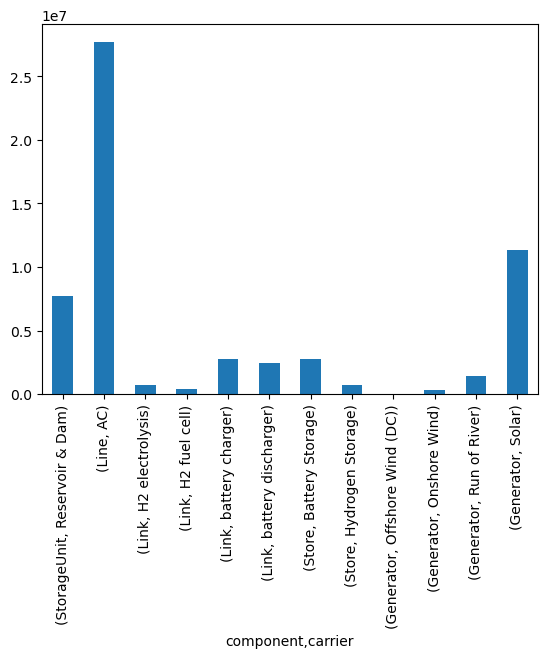

In [ ]:
n.statistics.supply().plot.bar()

/tmp/ipykernel_18353/968957247.py:1: DeprecatedWarning: dispatch is deprecated as of 0.28 and will be removed in 0.29. Use 'energy_balance' instead.
  (n.statistics.dispatch() / 1e6).plot.bar()


<AxesSubplot:xlabel='component,carrier'>

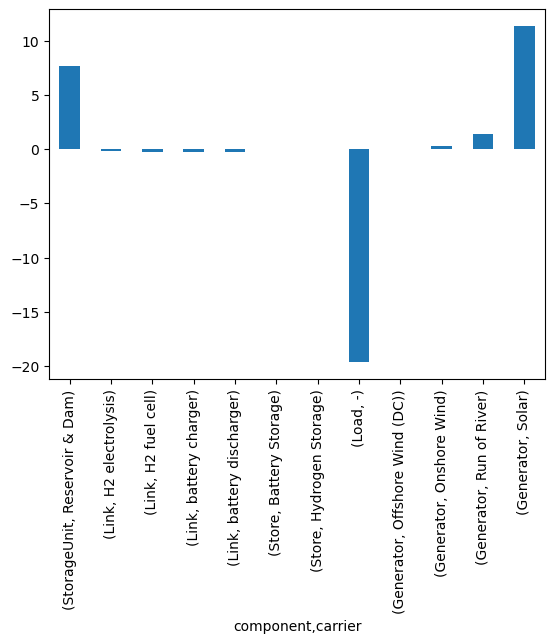

In [ ]:
(n.statistics.dispatch() / 1e6).plot.bar()